In [1]:
import matplotlib.pyplot as pl
import numpy as np
import os

from astropy.io import fits
from astropy.visualization import ZScaleInterval
from petitRADTRANS import physical_constants as nc  
from petitRADTRANS.radtrans import Radtrans 
from petitRADTRANS.chemistry.pre_calculated_chemistry import PreCalculatedEquilibriumChemistryTable
from petitRADTRANS.chemistry.utils import compute_mean_molar_masses
from petitRADTRANS.physics import temperature_profile_function_guillot_global as get_tprofile, rebin_spectrum_bin, rebin_spectrum
from petitRADTRANS.chemistry.prt_molmass import get_species_molar_mass

from lcr_atm import calc_ts_prt_guillot, calc_teq
from pytransit.orbits import as_from_rhop

infile = '/home/ubuntu/work/lcretrieval/results/HD209458b/results-260508-joint-pix/HD209458b.fits'
species_names = ["H2O", "CO", "CO2", "CH4", "NH3", "SiO", "C2H2", "HCN", "K", "Na", "FeH", "TiO", "VO", "H2S"]

planet_radius = 1.39 # R_jup
star_radius = 1.19 # R_sun  

atmosphere = Radtrans(
            pressures = np.logspace(-8, 2, 121), 
            line_species = species_names, 
            rayleigh_species = ['H2', 'He'], 
            gas_continuum_contributors = ['H2--H2', 'H2--He'], 
            wavelength_boundaries = [0.28, 5.1],
            line_opacity_mode = 'lbl', 
            line_by_line_opacity_sampling=10,
            )
wavelengths = 1e4 * atmosphere.get_wavelengths() # from cm to micron
pres_bar = atmosphere.pressures*1e-6 # cgs to bar

chem = PreCalculatedEquilibriumChemistryTable()

QUENCH_ID = np.where(atmosphere.pressures*1e-6 >= 1e-7)[0][0]

Loading Radtrans opacities...
 Loading line opacities of species 'H2O' from file '/home/ubuntu/petitRADTRANS/input_data/opacities/lines/line_by_line/H2O/1H2-16O/1H2-16O__POKAZATEL.R15000_0.3-50mu.xsec.TauREx.h5'... Done.
 Loading line opacities of species 'CO' from file '/home/ubuntu/petitRADTRANS/input_data/opacities/lines/line_by_line/CO/12C-16O/12C-16O__Li2015.R15000_0.3-50mu.xsec.TauREx.h5'... Done.
 Loading line opacities of species 'CO2' from file '/home/ubuntu/petitRADTRANS/input_data/opacities/lines/line_by_line/CO2/12C-16O2/12C-16O2__UCL-4000.R15000_0.3-50mu.xsec.TauREx.h5'... Done.
 Loading line opacities of species 'CH4' from file '/home/ubuntu/petitRADTRANS/input_data/opacities/lines/line_by_line/CH4/12C-1H4/12C-1H4__MM.R15000_0.3-50mu.xsec.TauREx.h5'... Done.
 Loading line opacities of species 'NH3' from file '/home/ubuntu/petitRADTRANS/input_data/opacities/lines/line_by_line/NH3/14N-1H3/14N-1H3__CoYuTe.R15000_0.3-50mu.xsec.TauREx.h5'... Done.
 Loading line opacities of sp

(0.0, 3000.0)

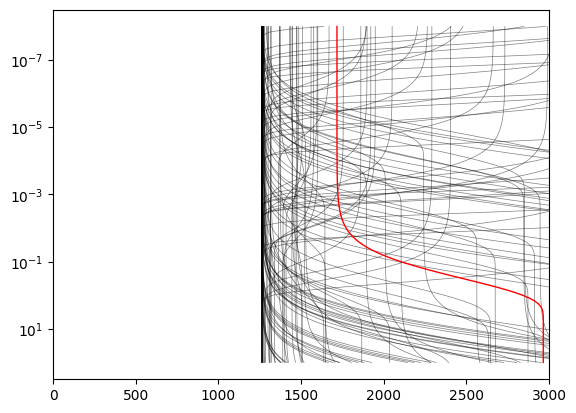

In [68]:
fig, ax = pl.subplots()

for i in range(100):
    _kir = 10**np.random.uniform(-5, 3)
    _gamma = 10**np.random.uniform(-3, 3) 

    t = get_tprofile(pres_bar, _kir, _gamma, 1000, 50, 1500)
    ax.plot(t, pres_bar, lw=0.5, color='k', alpha=0.5)

t = get_tprofile(pres_bar, 10**-2, 10**-1, 1000, 50, 2000)
ax.plot(t, pres_bar, lw=1, color='r', zorder=9)

ax.invert_yaxis()
ax.set_yscale('log')
ax.set_xlim(0, 3000)
# ax.set_xscale('log')


In [ ]:
hdul = fits.open(infile)
postsamples = hdul['MCMC'].data
atm_params = np.array([
    postsamples['mp'],
    postsamples['ref_p'],
    postsamples['cloud_p'],
    postsamples['kir'],
    postsamples['gamma'],
    postsamples['tint'],
    postsamples['ab'],
    postsamples['m2h'],
    postsamples['c2o'], 
    postsamples['cloud_f'] 
])
atm_params = atm_params.T 

In [ ]:
""" Maximum likelihood model """

prob_file = os.path.join(os.path.dirname(infile), 'lnprob.txt')
lnprobs = np.loadtxt(prob_file) 
maxlike_id = lnprobs.flatten().argmax()
maxlike_params = atm_params[maxlike_id]

_rho =  postsamples['rho'][maxlike_id]
_teff = postsamples['teff'][maxlike_id]
_per = postsamples['p'][maxlike_id]
_ab = postsamples['ab'][maxlike_id]
a_rs = as_from_rhop(_rho, _per)
teq = calc_teq(teff=_teff, a_rs=a_rs, albedo=_ab)

ts_bestfit, add_output = calc_ts_prt_guillot(
    maxlike_params, atmosphere, chem, 
    planet_radius_cm=planet_radius * nc.r_jup_mean,
    star_radius_cm=star_radius * nc.r_sun, 
    equilibrium_temperature=teq, 
    quench_id=QUENCH_ID,
    return_contribution=True
)
 
 
contributions = add_output['transmission_contribution']


Loading chemical equilibrium chemistry table from file '/home/ubuntu/petitRADTRANS/input_data/pre_calculated_chemistry/equilibrium_chemistry/equilibrium_chemistry.chemtable.petitRADTRANS.h5'... Done.


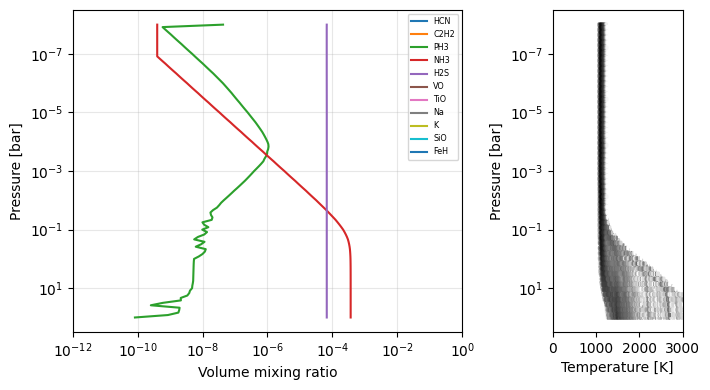

In [51]:
fig, ax = pl.subplots(1, 2, figsize=(7.2, 4), gridspec_kw={'width_ratios': [3, 1]})

planet_mass = maxlike_params[0] * nc.m_jup # g  
kir = 10**maxlike_params[3]
gamma = 10**maxlike_params[4]
tint = maxlike_params[5] # K 
metals = np.full_like(pres_bar, maxlike_params[7])
c2o_ratios = np.full_like(pres_bar, maxlike_params[8])

ref_gravity = nc.G * planet_mass / (planet_radius * nc.r_jup_mean)**2 

temperatures = get_tprofile(
    pressures=pres_bar,
    infrared_mean_opacity=kir,
    gamma=gamma,
    gravities=ref_gravity,
    intrinsic_temperature=tint,
    equilibrium_temperature=teq,
)

mass_fractions = chem.interpolate_mass_fractions(
    co_ratios=c2o_ratios,
    log10_metallicities=metals,
    temperatures=temperatures*0 + 500,
    pressures=pres_bar,
    full=False
)  

for sp in species_names:
    mass_fractions[sp][:QUENCH_ID] = mass_fractions[sp][QUENCH_ID]

mmw = compute_mean_molar_masses(mass_fractions)

for i, sp in enumerate(mass_fractions.keys()):
    if sp in ['H2', 'He', "H", "H-", "e-", "CO", "CO2", "H2O", "CH4"]:
        continue
    mixing_ratios = mass_fractions[sp] * mmw / get_species_molar_mass(sp)
    ax[0].plot(mixing_ratios, pres_bar, label=sp)

pres_plot = []
temp_plot = []
for p in atm_params[-20000:]:
    planet_mass = p[0] * nc.m_jup # g
    kir = 10**p[3]
    gamma = 10**p[4]
    tint = p[5]
    ab = p[6]
    teq = calc_teq(teff=_teff, a_rs=a_rs, albedo=ab)
    ref_gravity = nc.G * planet_mass / (planet_radius * nc.r_jup_mean)**2 
    temp = get_tprofile(
        pressures=pres_bar,
        infrared_mean_opacity=kir,
        gamma=gamma,
        gravities=ref_gravity,
        intrinsic_temperature=tint,
        equilibrium_temperature=teq,
    )
    pres_plot.extend(pres_bar)
    temp_plot.extend(temp)
    # ax[1].plot(temp, pres_bar, lw=0.5, alpha=0.1, c='k')
ax[1].hexbin(temp_plot, pres_plot, gridsize=100, mincnt=1, cmap='Greys', yscale='log', norm='log')

ax[0].set_xscale('log')
ax[0].set_yscale('log')
ax[0].set_ylabel('Pressure [bar]')
ax[0].set_xlabel('Volume mixing ratio')
ax[0].set_xlim(1e-12, 1) 
ax[0].grid(alpha=0.3)
ax[0].invert_yaxis()
ax[0].legend(fontsize='xx-small') 
ax[1].set_xlim(0, 3000)
ax[1].set_xlabel('Temperature [K]')
ax[1].set_yscale('log') 
ax[1].set_ylabel('Pressure [bar]')
ax[1].invert_yaxis()
fig.tight_layout()
# fig.savefig('chemistry.png', dpi=100)

In [41]:
mass_fractions.keys()

dict_keys(['H2', 'He', 'CO', 'H2O', 'HCN', 'C2H2', 'CH4', 'PH3', 'CO2', 'NH3', 'H2S', 'VO', 'TiO', 'Na', 'K', 'SiO', 'e-', 'H-', 'H', 'FeH'])

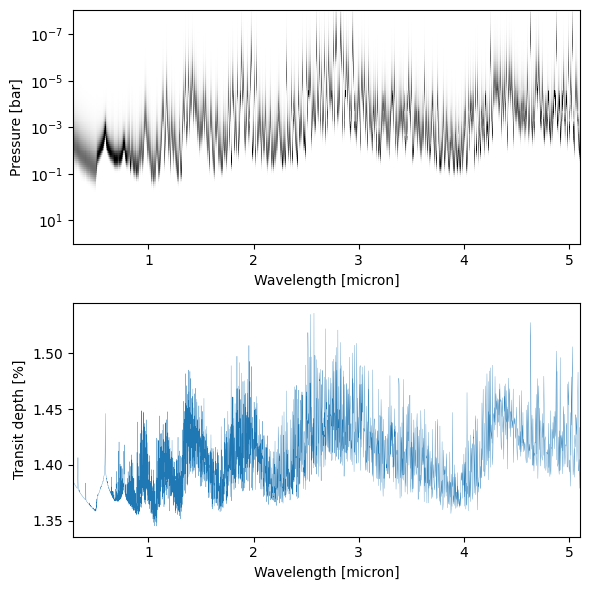

In [35]:
""" Contribution function """

fig, ax = pl.subplots(2, 1, figsize=(6,6),) 

zscale = ZScaleInterval(contrast=0.03)
vmin, vmax = zscale.get_limits(contributions)
a = ax[0].pcolormesh(wavelengths, pres_bar, contributions, shading='auto', vmin=vmin, vmax=vmax, cmap='gray_r')
ax[0].set_xlabel('Wavelength [micron]')
ax[0].set_ylabel('Pressure [bar]')
ax[0].set_yscale('log') 
ax[0].invert_yaxis() 

ax[1].plot(wavelengths, ts_bestfit*100, lw=0.2, zorder=0)  
ax[1].set_xlim(ax[0].get_xlim()) 
ax[1].set_xlabel('Wavelength [micron]')
ax[1].set_ylabel('Transit depth [%]')

fig.tight_layout()
# fig.savefig('contribution_function.png', dpi=100)

In [44]:
ts_samples = [] 
np.random.seed(42)
np.random.shuffle(atm_params)
sub_samples = atm_params[:200] 
for i, pv in enumerate(sub_samples):  
    teq = calc_teq(teff=_teff, a_rs=a_rs, albedo=pv[6])
    _ts = calc_ts_prt(
        pv, atmosphere, chem, 
        planet_radius_cm=planet_radius * nc.r_jup_mean,
        star_radius_cm=star_radius * nc.r_sun, 
        equilibrium_temperature=teq, 
        quench_id=QUENCH_ID,
    )

    ts_samples.append(_ts)


In [45]:
import tomllib
import h5py

cfgfile = "../results/HD209458b/results-260508-joint-pix/HD209458b_joint.toml"
cfg = tomllib.load(open(cfgfile, 'rb'))
raw_data  = [h5py.File(f, 'r') for f in cfg["PATH"]["input_file"]]

In [51]:
# HST/STIS_G430L
wl_rebinned = list(raw_data[0]["wavelength"][:])
bin_widths = list(np.squeeze(0.5*np.diff(raw_data[0]["wavelength_bins"][:])))

# HST/STIS_G750L
wl_rebinned += list(raw_data[2]["wavelength"][:])
bin_widths += list(np.squeeze(0.5*np.diff(raw_data[2]["wavelength_bins"][:])))

# HST/WFC3_G141
wl_rebinned += list(raw_data[4]["wavelength"][:])
bin_widths += list(np.squeeze(0.5*np.diff(raw_data[4]["wavelength_bins"][:])))

wl_start, wl_end, resolution = 2.5, 5.0, 100
len_wl = np.log(wl_end / wl_start) * resolution
len_wl = int(np.round(len_wl))
_wl = np.logspace(np.log10(wl_start), np.log10(wl_end), len_wl)
wl_rebinned += list(_wl[:-1])
bin_widths += list(np.diff(_wl))

wl_rebinned = np.array(wl_rebinned)
bin_widths = np.array(bin_widths)

ts_rebinned = [rebin_spectrum_bin(wavelengths, _s, wl_rebinned, bin_widths) \
    for _s in ts_samples]
ts_rebinned = np.array(ts_rebinned)

ts_median = np.median(ts_rebinned, axis=0)
ts_error = np.std(ts_rebinned, axis=0)
ts_up = np.percentile(ts_rebinned, 99.865, axis=0)
ts_lo = np.percentile(ts_rebinned, 0.135, axis=0)

wl_start, wl_end, resolution = 0.3, 5.0, 100
len_wl = np.log(wl_end / wl_start) * resolution
len_wl = int(np.round(len_wl))
wl_bestfit_rebinned = np.logspace(np.log10(wl_start), np.log10(wl_end), len_wl)
ts_bestfit_rebinned = rebin_spectrum(wavelengths, ts_bestfit, wl_bestfit_rebinned)

split_id = 1 + np.where(np.diff(wl_rebinned) > 0.1)[0]
wl_groups = np.split(wl_rebinned, split_id)
ts_groups = np.split(ts_median, split_id)
ts_up_groups = np.split(ts_up, split_id)
ts_lo_groups = np.split(ts_lo, split_id)

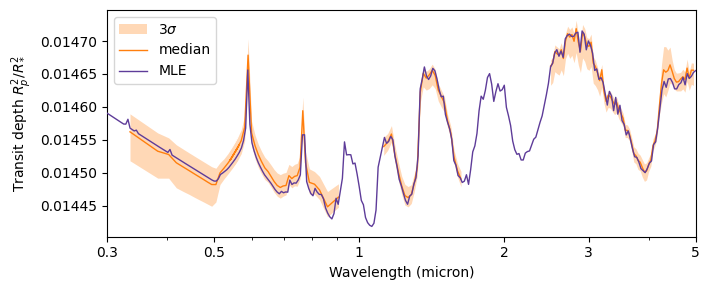

In [52]:

fig, ax = pl.subplots(1,1, figsize=(7.2, 3))  
for i, (wl_g, ts_g, ts_up_g, ts_lo_g) in enumerate(zip(wl_groups, ts_groups, ts_up_groups, ts_lo_groups)):
    ax.fill_between(wl_g, ts_lo_g, ts_up_g, 
        color='C1', alpha=0.3, lw=0, zorder=1, label=r'3$\sigma$' if i==0 else None) 
    ax.plot(wl_g, ts_g, lw=1, label='median' if i==0 else None, color='C1', zorder=3) 
ax.plot(wl_bestfit_rebinned, ts_bestfit_rebinned, lw=1, label='MLE', color='#5e3c99', zorder=4) 
ax.set_xlabel('Wavelength (micron)')
ax.set_ylabel('Transit depth $R_p^2/R_*^2$')
ax.legend(ncol=1, loc='upper left')
ax.set_xscale('log') 
ax.set_xticks([0.3, 0.5, 1, 2, 3, 5], [0.3, 0.5, 1, 2, 3, 5])
ax.set_xlim(wl_bestfit_rebinned.min(), wl_bestfit_rebinned.max())
fig.tight_layout()
fig.savefig('post_spectrum.png', dpi=100)
